In [20]:
# forgot to create graphs of optuna run for report like the ultralytics stuff 
import csv
import re
import ast
import matplotlib.pyplot as plt
import numpy as np
path_to_logs = '/home/links/lf507/Dark-ship-detection/runs/optuna_logs.txt'

with open(path_to_logs, 'r') as f:
    reader = f.readlines()
    data = list(reader)
# parse with Regex
data = [x for x in data if 'finished with value' in x] # filter out non-numeric rows (headers, etc.)


In [21]:
perf = []
for log_string in data:
    # print(log_string)
    value_match = re.search(r"value: ([\d\.]+)", log_string)
    perf.append(float(value_match.group(1)) if value_match else None)


    params_match = re.search(r"parameters: (\{.*?\})", log_string)
    params_dict = ast.literal_eval(params_match.group(1)) if params_match else None
    # print(params_dict)


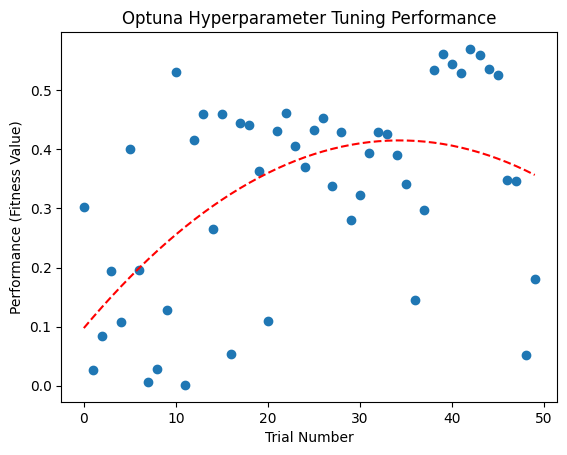

In [ ]:
plt.scatter(range(len(perf)), perf)
plt.xlabel('Trial Number')
plt.ylabel('Performance (Fitness Value)')
plt.title('Optuna Hyperparameter Tuning Performance')
# add smooth trend line
z = np.polyfit(range(len(perf)), perf, 3)  # 3rd degree polynomial
p = np.poly1d(z)
plt.plot(range(len(perf)), p(range(len(perf))), "r--")
plt.show()